## Task 1 (Entrega Parcial)


### Task 1.1

Antes de implementar cualquier algoritmo, el equipo de ingeniería necesita una justificación técnica sólida
de las decisiones de diseño.


a. El espacio de acción del sistema de control de palas es continuo. Argumenten formalmente por qué DQN y sus variantes de la semana anterior son inapropiados para este dominio. Su argumento debe mencionar explícitamente el operador argmax, el espacio de acción continuo, y las consecuencias computacionales de intentar aplicar DQN directamente.


DQN está diseñado para un conjunto de acciones discreto y finito. Su objetivo TD utiliza el target

$$y_t=r_t+\gamma(1-d_t)\max_{a'\in\mathcal A}Q_{\theta^-}(s_{t+1},a'),$$

donde la política implícita es $a^*(s)=\arg\max_{a\in\mathcal A}Q(s,a)$. El operador $\arg\max$ puede evaluarse enumerando las acciones porque DQN produce un valor de salida por cada acción discreta.

En el control de palas, $\mathcal A$ es continuo, por ejemplo un intervalo o un subconjunto de $\mathbb R^m$. Por tanto, hay infinitas acciones y una red DQN no puede tener una salida por cada una. Aplicar directamente el mismo operador exigiría resolver, para cada siguiente estado y para cada actualización, el problema de optimización continua $\max_{a'}Q(s_{t+1},a')$. Esa optimización sería costosa, posiblemente no convexa y tendría que repetirse millones de veces durante el entrenamiento; además, el gradiente del `argmax` no es adecuado para el entrenamiento estándar de DQN.

Discretizar el intervalo tampoco elimina el problema: una discretización fina produce muchas acciones y, si hay varias palas o actuadores, el número de combinaciones crece exponencialmente con la dimensión. Una discretización gruesa introduce error de cuantización y puede generar comandos físicamente inadecuados. Las variantes de DQN conservan esta dependencia del máximo sobre acciones discretas, por lo que no son la elección apropiada. Algoritmos actor--critic como TD3 y SAC parametrizan directamente una acción continua y evitan enumerar todo el espacio.


b. Entre TD3 y SAC, ¿cuál recomendarían para el sistema de control de turbinas eólicas en producción? Justifiquen considerando: la naturaleza física del sistema (¿es deseable una política estocástica en un sistema de control industrial?), la eficiencia de datos durante el entrenamiento en simulación, y la robustez ante perturbaciones de viento no vistas durante el entrenamiento. Su respuesta debe argumentar ambos lados antes de tomar posición.


Ambos métodos son off-policy y reutilizan el replay buffer, por lo que son mucho más eficientes en datos que un método on-policy. TD3 aprende una política determinista $\mu_\theta(s)$ y usa dos críticos, el mínimo entre ellos, actualización retardada del actor y suavizado del target. Esto reduce el sobreestimado de $Q$ y produce comandos repetibles, una propiedad valiosa cuando una variación aleatoria del pitch o del torque puede aumentar cargas estructurales, fatiga o desgaste del actuador. En un simulador suave y suficientemente fiel, TD3 suele ser una opción muy eficiente y directa para control continuo.

SAC, por otro lado, optimiza recompensa más entropía. Su política Gaussiana reparametrizada explora de forma explícita y el ajuste automático de $\alpha$ evita fijar manualmente el nivel de exploración. Esa diversidad de acciones puede ayudar a escapar de soluciones locales y a aprender una política menos frágil frente a cambios de turbulencia, densidad del aire o velocidad del viento que no estaban presentes en el entrenamiento. También puede ser ventajosa si el simulador tiene incertidumbre y se desea que la política aprenda varias acciones razonables en un mismo estado.

La desventaja de SAC en producción es que su política es estocástica: la aleatoriedad útil durante entrenamiento no debe traducirse sin control a comandos del sistema físico. Además, el término de entropía puede favorecer acciones variadas aunque dos acciones tengan casi la misma recompensa, y su beneficio depende de calibrar correctamente $\alpha$ y de tener un simulador representativo. SAC puede ejecutarse usando la media de la política en despliegue, pero entonces parte de la motivación estocástica desaparece y aún se debe validar el comportamiento fuera de distribución.

**Recomendación:** elegiría **TD3 para el controlador de producción**, acompañado de límites físicos, un supervisor de seguridad y validación con perturbaciones de viento. La determinismo, el suavizado del target y la menor variabilidad de las acciones encajan mejor con un sistema industrial. Usaría SAC como referencia de entrenamiento o como candidato alternativo si los experimentos con turbulencias no vistas muestran una mejora clara y se puede filtrar la acción mediante una capa de seguridad. La decisión debe confirmarse con pruebas de robustez, no solo con la recompensa promedio.


c. La empresa tiene tres años de registros históricos generados por operadores humanos con distintos niveles de experiencia. Analicen si ese dataset es apropiado para aplicar CQL. Su análisis debe considerar: qué tipo de política de comportamiento 𝛽 generó los datos (¿es cercana a la óptima?), qué cobertura del espacio estado-acción se puede esperar de operadores humanos, y cuál de las dos condiciones de Offline RL es más difícil de satisfacer en este dominio específico.


El dataset puede ser apropiado para CQL, pero no garantiza por sí mismo una solución segura ni óptima. La política de comportamiento puede modelarse como una mezcla $\beta(a\mid s)=\sum_i w_i\beta_i(a\mid s)$, donde cada $\beta_i$ corresponde a un operador con diferente experiencia, criterio y tolerancia al riesgo. No es razonable asumir que $\beta$ sea cercana a la política óptima: los operadores suelen priorizar seguridad, estabilidad y protocolos conservadores, y pueden existir trayectorias subóptimas o decisiones inconsistentes. La heterogeneidad sí puede ser útil porque incorpora más de una estrategia y más estados operativos.

La cobertura será buena alrededor de los regímenes normales observados, pero probablemente pobre en combinaciones críticas: ráfagas extremas, fallas, recuperación después de saturación y acciones agresivas que un operador prudente evita probar. También puede haber poca cobertura de estados raros y de acciones continuas entre los comandos usados históricamente. La diversidad de operadores no equivale a exploración uniforme; puede repetir acciones seguras en la misma región del espacio.

Las dos condiciones prácticas de Offline RL son: (1) **cobertura o solapamiento**, es decir, que las acciones que la política aprendida quiera usar tengan soporte suficiente en el dataset; y (2) **calidad suficiente de los datos**, con trayectorias que contengan comportamiento competente y señales para distinguir decisiones buenas de malas. CQL ayuda con el error de extrapolación y puede trabajar con datos subóptimos, pero no puede inventar evidencia fiable para acciones o estados ausentes. En este dominio, la condición más difícil es la **cobertura en estados y acciones críticos**, porque la operación segura evita precisamente experimentar con ellos. Por tanto, aplicaría CQL con análisis de cobertura, separación por régimen de viento y validación en simulación antes de cualquier uso operativo.


d. Argumenten cuál es el riesgo principal de aplicar Q-Learning estándar directamente sobre el dataset histórico sin ninguna restricción de conservatividad. Usen el concepto de error de extrapolación y conéctenlo con una consecuencia operacional concreta para el sistema de turbinas.


El riesgo principal es que el Q-Learning offline seleccione acciones fuera de la distribución del dataset porque el máximo del backup favorece cualquier error positivo del aproximador. Si una acción $(s,a)$ casi nunca aparece, su valor se obtiene por extrapolación de la red; ese error puede ser grande y positivo. El operador $\max_a Q(s,a)$ convierte ese error en una acción elegida por la política y, mediante el bootstrapping, lo propaga a estados anteriores. Es el llamado **error de extrapolación** o distribución fuera de soporte.

En una turbina, el resultado puede ser que el controlador prefiera un ángulo de pala o un torque que parece excelente para el modelo, pero nunca fue validado por los operadores en ese estado de viento. El comando podría saturar el actuador, producir oscilaciones de carga, aumentar la fatiga, llevar el rotor a una condición de sobrevelocidad o provocar una parada de emergencia. La recompensa estimada sería optimista mientras el sistema real sufriría una degradación o una condición insegura; por eso se necesita una penalización conservadora, restricciones de acción y una capa independiente de protección.


### Task 1.2

El equipo quiere entender las diferencias matemáticas entre los algoritmos antes de implementarlos.


a. Escriban el objetivo de optimización de SAC incluyendo el término de entropía. Identifiquen cada variable con su significado en el contexto del sistema de turbinas: ¿qué representa 𝛼, qué representa ℋ(𝜋(⋅∣ 𝑆𝑡)), y cómo se calibraría 𝛼 automáticamente durante el entrenamiento?


**Respuesta.** El objetivo de SAC puede escribirse como

$$J(\pi)=\mathbb E_{\tau\sim\pi}\left[\sum_{t=0}^{\infty}\gamma^t\left(r(s_t,a_t)+\alpha\,\mathcal H(\pi(\cdot\mid s_t))\right)\right],$$

con
$$\mathcal H(\pi(\cdot\mid s))=-\mathbb E_{a\sim\pi(\cdot\mid s)}[\log\pi(a\mid s)].$$

$s_t$ contiene el estado operativo de la turbina (por ejemplo, velocidad del rotor, viento y cargas), $a_t$ es el comando continuo de pitch/torque, $r$ mide desempeño y seguridad, y $\gamma$ descuenta el futuro. $\mathcal H$ mide la incertidumbre o diversidad de acciones que la política mantiene en un estado. $\alpha>0$ es la temperatura de entropía: un valor alto prioriza exploración y tolerancia a varias acciones, mientras que un valor bajo prioriza maximizar la recompensa y hace la política más determinista.

Para ajustar $\alpha$ automáticamente se fija una entropía objetivo $\bar{\mathcal H}$ y se optimiza $\log\alpha$ como variable libre. En la convención usual de SAC para acciones continuas se toma $\bar{\mathcal H}=-\dim(\mathcal A)$, como solicita el enunciado. La pérdida de temperatura es

$$L_{\log\alpha}=\mathbb E_{s\sim D,,a\sim\pi}\left[-\log\alpha\,\bigl(\log\pi(a\mid s)+\bar{\mathcal H}\bigr)\right].$$

La actualización aumenta $\alpha$ cuando la entropía observada está por debajo del objetivo y la reduce cuando está por encima. En control real, la acción usada al evaluar o desplegar debe pasar además por límites, rate limiters y verificaciones de seguridad.


b. Comparen el target de actualización del Critic en TD3 versus SAC. ¿Cuál de los dos produce estimaciones más conservadoras del valor y por qué? ¿Esa conservatividad es una ventaja o una desventaja para el dominio de turbinas?


En TD3, el target del crítico es

$$y_t^{TD3}=r_t+\gamma(1-d_t)\min_{i\in\{1,2\}}Q_{\phi_i^-}\left(s_{t+1},\mu_{\theta^-}(s_{t+1})+\operatorname{clip}(\epsilon,-c,c)\right),$$

donde $\epsilon\sim\mathcal N(0,\sigma^2)$ y la acción se recorta al rango válido. En SAC, usando la misma convención de dos críticos,

$$y_t^{SAC}=r_t+\gamma(1-d_t)\left[\min_{i\in\{1,2\}}Q_{\phi_i^-}(s_{t+1},a_{t+1})-\alpha\log\pi_\theta(a_{t+1}\mid s_{t+1})\right],$$

con $a_{t+1}\sim\pi_\theta(\cdot\mid s_{t+1})$. Ambos usan el mínimo de dos críticos, lo que reduce el sobreestimado. Sin embargo, el término $-\alpha\log\pi$ es un bono de entropía: en promedio añade $\alpha\mathcal H$ al valor soft. Por ello, **en magnitud numérica y manteniendo iguales los críticos, TD3 suele producir el target más conservador**; SAC puede tener un valor soft mayor aunque su mínimo de críticos también controle el optimismo. El suavizado de TD3 añade además tolerancia a pequeños errores alrededor de la acción seleccionada.

En turbinas, cierta conservatividad es una ventaja: reduce la probabilidad de que el controlador elija una acción no validada por una sobreestimación del modelo. El exceso de conservatividad también es una desventaja porque puede producir control tímido, menor captura de energía o rechazo de maniobras útiles. La solución práctica es combinar el crítico conservador con recompensas que penalicen cargas y saturación, calibrar $\alpha$ y validar rendimiento y seguridad bajo perturbaciones.


c. Escriban el objetivo de CQL identificando los dos términos que se añaden a la pérdida TD estándar. Expliquen en palabras qué hace cada término y por qué su combinación produce un Critic conservador. Luego argumenten qué valor de 𝛼𝐶𝑄𝐿 recomendarían para el dataset de turbinas considerando la heterogeneidad de los operadores que lo generaron.


Para acciones continuas, una forma de CQL es

$$L_{CQL}(Q)=L_{TD}(Q)+\alpha_{CQL}\,\mathbb E_{s\sim D}\left[\underbrace{\log\int_{\mathcal A}\exp(Q(s,a))\,da}_{\text{término log-sum-exp}}-\underbrace{\mathbb E_{a\sim D(\cdot\mid s)}Q(s,a)}_{\text{término de acciones del dataset}}\right].$$

En implementación, la integral se aproxima con acciones muestreadas de la política, del prior/uniforme y del dataset. Los dos términos añadidos son, por tanto, (1) el **log-sum-exp**, que penaliza valores altos en cualquier acción considerada, especialmente acciones fuera de distribución; y (2) el término negativo sobre acciones observadas, que evita penalizar de la misma manera las acciones respaldadas por datos y las mantiene como referencia. La combinación reduce $Q$ donde el crítico no tiene evidencia y conserva valores relativamente mayores en el soporte del dataset. Así, la política deja de explotar errores positivos de extrapolación.

Para los registros de operadores heterogéneos recomendaría comenzar con $\alpha_{CQL}=1.0$. Es un compromiso razonable: aporta conservatividad ante acciones poco respaldadas sin borrar por completo las diferencias entre operadores expertos y novatos. Probaría $0.5$ y $5.0$ como análisis de sensibilidad; usaría $5.0$ si la auditoría confirma cobertura muy pobre en regiones críticas y se prioriza seguridad, pero vigilaría el subestimado y el colapso hacia una política excesivamente imitativa. La selección final debe hacerse con validación por régimen de viento, métricas de seguridad y evaluación en simulación, no únicamente con la pérdida CQL.


## Task 2


### Task 2.1

Implementen TD3 y SAC sobre el entorno Pendulum-v1 de Gymnasium como proxy del sistema de control de turbinas. Este entorno tiene espacio de acción continuo unidimensional en [−2,2] y estado tridimensional, lo que lo hace apropiado para validar las propiedades algorítmicas antes de escalar al dominio real.

Ambos algoritmos deben implementarse desde cero usando PyTorch. No se permite usar implementaciones preconstruidas de TD3 o SAC de ninguna librería de RL. Usen las siguientes especificaciones compartidas para ambos: buffer de Experience Replay con capacidad de 100,000 transiciones, minibatch de 256 transiciones, Target Networks con actualización suave 𝜏 = 0.005, dos capas ocultas de 256 neuronas con activación ReLU, y entrenamiento durante 100,000 pasos de ambiente.

Para TD3 específicamente: Twin Critics, Policy Delay de 2 pasos, y Target Policy Smoothing con 𝜎 = 0.2 y clip c = 0.5.

Para SAC específicamente: política Gaussiana reparametrizada con tanh aplicado a la salida para restringir acciones al rango válido, Twin Critics, y 𝛼 ajustado automáticamente con entropía objetivo −dim(𝒜).

La implementación debe registrar por cada 1,000 pasos: recompensa promedio de evaluación greedy sobre 10 episodios, valor Q promedio estimado sobre un conjunto fijo de 1,000 transiciones, y entropía de la política (solo para SAC).


In [1]:
# %pip install torch
# %pip install gymnasium



In [2]:

import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import gymnasium as gym


In [3]:

SEED = 7
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BUFFER_CAPACITY = 100_000
BATCH_SIZE = 256
TAU = 0.005
GAMMA = 0.99
HIDDEN_SIZE = 256
TOTAL_STEPS = 100_000
EVAL_INTERVAL = 1_000
EVAL_EPISODES = 10

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()
print('Device:', DEVICE)


Device: cpu


In [4]:
class ReplayBuffer:
    def __init__(self, state_dim, action_dim, capacity=BUFFER_CAPACITY, device=DEVICE):
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.not_done = np.ones((capacity, 1), dtype=np.float32)
        self.capacity = capacity
        self.device = device
        self.ptr = 0
        self.size = 0

    def add(self, state, action, reward, next_state, terminated):
        i = self.ptr
        self.states[i] = state
        self.actions[i] = action
        self.rewards[i] = reward
        self.next_states[i] = next_state
        self.not_done[i] = 1.0 - float(terminated)
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return self._to_tensors(idx)

    def fixed_sample(self, n=1000):
        replace = self.size < n
        idx = np.random.choice(self.size, size=n, replace=replace)
        return self._to_tensors(idx)

    def _to_tensors(self, idx):
        arrays = (self.states[idx], self.actions[idx], self.rewards[idx], self.next_states[idx], self.not_done[idx])
        return tuple(torch.as_tensor(x, dtype=torch.float32, device=self.device) for x in arrays)

def mlp(input_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, HIDDEN_SIZE), nn.ReLU(),
        nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE), nn.ReLU(),
        nn.Linear(HIDDEN_SIZE, output_dim)
    )

class TwinCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.q1_net = mlp(state_dim + action_dim, 1)
        self.q2_net = mlp(state_dim + action_dim, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.q1_net(x), self.q2_net(x)

    def q1(self, state, action):
        return self.q1_net(torch.cat([state, action], dim=-1))

class DeterministicActor(nn.Module):
    def __init__(self, state_dim, action_low, action_high):
        super().__init__()
        self.net = mlp(state_dim, len(action_low))
        low = torch.as_tensor(action_low, dtype=torch.float32)
        high = torch.as_tensor(action_high, dtype=torch.float32)
        self.register_buffer('action_scale', (high - low) / 2.0)
        self.register_buffer('action_bias', (high + low) / 2.0)

    def forward(self, state):
        return self.action_bias + self.action_scale * torch.tanh(self.net(state))

class GaussianActor(nn.Module):
    def __init__(self, state_dim, action_low, action_high):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_SIZE), nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE), nn.ReLU()
        )
        self.mean = nn.Linear(HIDDEN_SIZE, len(action_low))
        self.log_std = nn.Linear(HIDDEN_SIZE, len(action_low))
        low = torch.as_tensor(action_low, dtype=torch.float32)
        high = torch.as_tensor(action_high, dtype=torch.float32)
        self.register_buffer('action_scale', (high - low) / 2.0)
        self.register_buffer('action_bias', (high + low) / 2.0)

    def forward(self, state):
        h = self.backbone(state)
        mean = self.mean(h)
        log_std = self.log_std(h).clamp(-20.0, 2.0)
        return mean, log_std

    def sample(self, state, deterministic=False):
        mean, log_std = self(state)
        if deterministic:
            z = mean
        else:
            z = Normal(mean, log_std.exp()).rsample()
        squashed = torch.tanh(z)
        action = self.action_bias + self.action_scale * squashed
        if deterministic:
            return action, None
        normal = Normal(mean, log_std.exp())
        log_prob = normal.log_prob(z)
        correction = torch.log(self.action_scale * (1.0 - squashed.pow(2)) + 1e-6)
        return action, (log_prob - correction).sum(dim=-1, keepdim=True)

def soft_update(source, target, tau=TAU):
    for source_param, target_param in zip(source.parameters(), target.parameters()):
        target_param.data.mul_(1.0 - tau).add_(tau * source_param.data)


In [4]:
class TD3Agent:
    def __init__(self, state_dim, action_low, action_high, gamma=GAMMA, tau=TAU,
                 policy_noise=0.2, noise_clip=0.5, policy_delay=2):
        self.actor = DeterministicActor(state_dim, action_low, action_high).to(DEVICE)
        self.actor_target = copy.deepcopy(self.actor).to(DEVICE)
        self.critic = TwinCritic(state_dim, len(action_low)).to(DEVICE)
        self.critic_target = copy.deepcopy(self.critic).to(DEVICE)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=3e-4)
        self.gamma = gamma
        self.tau = tau
        self.policy_noise = policy_noise
        self.noise_clip = noise_clip
        self.policy_delay = policy_delay
        self.action_low = torch.as_tensor(action_low, dtype=torch.float32, device=DEVICE)
        self.action_high = torch.as_tensor(action_high, dtype=torch.float32, device=DEVICE)
        self.update_step = 0

    @torch.no_grad()
    def act(self, state):
        state_t = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        return self.actor(state_t).cpu().numpy()[0]

    def update(self, replay, batch_size=BATCH_SIZE):
        self.update_step += 1
        state, action, reward, next_state, not_done = replay.sample(batch_size)
        with torch.no_grad():
            noise = (torch.randn_like(action) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
            next_action = (self.actor_target(next_state) + noise).clamp(self.action_low, self.action_high)
            target_q1, target_q2 = self.critic_target(next_state, next_action)
            target = reward + self.gamma * not_done * torch.minimum(target_q1, target_q2)
        current_q1, current_q2 = self.critic(state, action)
        critic_loss = (current_q1 - target).pow(2).mean() + (current_q2 - target).pow(2).mean()
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        actor_loss = torch.tensor(0.0, device=DEVICE)
        if self.update_step % self.policy_delay == 0:
            actor_action = self.actor(state)
            actor_loss = -self.critic.q1(state, actor_action).mean()
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()
            soft_update(self.actor, self.actor_target, self.tau)
            soft_update(self.critic, self.critic_target, self.tau)
        return {'critic_loss': critic_loss.item(), 'actor_loss': actor_loss.item()}

    @torch.no_grad()
    def mean_q(self, fixed_batch):
        state, action = fixed_batch[0], fixed_batch[1]
        q1, q2 = self.critic(state, action)
        return torch.minimum(q1, q2).mean().item()

class SACAgent:
    def __init__(self, state_dim, action_low, action_high, gamma=GAMMA, tau=TAU):
        action_dim = len(action_low)
        self.actor = GaussianActor(state_dim, action_low, action_high).to(DEVICE)
        self.critic = TwinCritic(state_dim, action_dim).to(DEVICE)
        self.critic_target = copy.deepcopy(self.critic).to(DEVICE)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=3e-4)
        self.log_alpha = torch.tensor(np.log(0.2), dtype=torch.float32, device=DEVICE, requires_grad=True)
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=3e-4)
        self.target_entropy = -float(action_dim)
        self.gamma = gamma
        self.tau = tau

    @property
    def alpha(self):
        return self.log_alpha.exp()

    @torch.no_grad()
    def act(self, state):
        state_t = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        action, _ = self.actor.sample(state_t, deterministic=True)
        return action.cpu().numpy()[0]

    def update(self, replay, batch_size=BATCH_SIZE):
        state, action, reward, next_state, not_done = replay.sample(batch_size)
        with torch.no_grad():
            next_action, next_log_prob = self.actor.sample(next_state)
            target_q1, target_q2 = self.critic_target(next_state, next_action)
            target = reward + self.gamma * not_done * (torch.minimum(target_q1, target_q2) - self.alpha * next_log_prob)
        current_q1, current_q2 = self.critic(state, action)
        critic_loss = (current_q1 - target).pow(2).mean() + (current_q2 - target).pow(2).mean()
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        new_action, log_prob = self.actor.sample(state)
        q1_new, q2_new = self.critic(state, new_action)
        actor_loss = (self.alpha.detach() * log_prob - torch.minimum(q1_new, q2_new)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()
        soft_update(self.critic, self.critic_target, self.tau)
        return {'critic_loss': critic_loss.item(), 'actor_loss': actor_loss.item(), 'alpha': self.alpha.item(), 'alpha_loss': alpha_loss.item()}

    @torch.no_grad()
    def mean_q(self, fixed_batch):
        state, action = fixed_batch[0], fixed_batch[1]
        q1, q2 = self.critic(state, action)
        return torch.minimum(q1, q2).mean().item()

    @torch.no_grad()
    def entropy(self, states):
        _, log_prob = self.actor.sample(states)
        return (-log_prob).mean().item()


In [5]:
def evaluate_agent(agent, env_name='Pendulum-v1', episodes=10, seed=SEED):
    env = gym.make(env_name)
    returns = []
    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        done = False
        total = 0.0
        while not done:
            action = agent.act(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
        returns.append(total)
    env.close()
    return float(np.mean(returns)), float(np.std(returns))

def _make_env_info(env_name='Pendulum-v1', seed=SEED):
    env = gym.make(env_name)
    state_dim = int(np.prod(env.observation_space.shape))
    action_low = env.action_space.low.astype(np.float32)
    action_high = env.action_space.high.astype(np.float32)
    state, _ = env.reset(seed=seed)
    return env, state_dim, action_low, action_high, state

def _fixed_entropy(agent, fixed_batch):
    return agent.entropy(fixed_batch[0]) if isinstance(agent, SACAgent) else np.nan

def train_td3(total_steps=TOTAL_STEPS, eval_interval=EVAL_INTERVAL, eval_episodes=EVAL_EPISODES,
               env_name='Pendulum-v1', seed=SEED, record_metrics=True):
    seed_everything(seed)
    env, state_dim, action_low, action_high, state = _make_env_info(env_name, seed)
    agent = TD3Agent(state_dim, action_low, action_high)
    replay = ReplayBuffer(state_dim, len(action_low))
    warmup = min(1_000, total_steps)
    fixed_batch = None
    records = []
    for step in range(1, total_steps + 1):
        if step <= warmup:
            action = env.action_space.sample()
        else:
            action = agent.act(state) + np.random.normal(0.0, 0.1, size=action_low.shape)
            action = np.clip(action, action_low, action_high)
        next_state, reward, terminated, truncated, _ = env.step(action)
        replay.add(state, action, reward, next_state, terminated)
        state = next_state
        if terminated or truncated:
            state, _ = env.reset()
        if replay.size >= BATCH_SIZE:
            agent.update(replay)
        if record_metrics and step % eval_interval == 0:
            if fixed_batch is None and replay.size >= 1_000:
                fixed_batch = replay.fixed_sample(1_000)
            avg_return, std_return = evaluate_agent(agent, env_name, eval_episodes, seed + step)
            q_mean = agent.mean_q(fixed_batch) if fixed_batch is not None else np.nan
            records.append({'step': step, 'eval_return': avg_return, 'eval_std': std_return,
                            'q_mean': q_mean, 'entropy': np.nan})
    env.close()
    return agent, replay, pd.DataFrame(records)

def train_sac(total_steps=TOTAL_STEPS, eval_interval=EVAL_INTERVAL, eval_episodes=EVAL_EPISODES,
               env_name='Pendulum-v1', seed=SEED, record_metrics=True):
    seed_everything(seed)
    env, state_dim, action_low, action_high, state = _make_env_info(env_name, seed)
    agent = SACAgent(state_dim, action_low, action_high)
    replay = ReplayBuffer(state_dim, len(action_low))
    warmup = min(1_000, total_steps)
    fixed_batch = None
    records = []
    for step in range(1, total_steps + 1):
        if step <= warmup:
            action = env.action_space.sample()
        else:
            action = agent.act(state) + np.random.normal(0.0, 0.1, size=action_low.shape)
            action = np.clip(action, action_low, action_high)
        next_state, reward, terminated, truncated, _ = env.step(action)
        replay.add(state, action, reward, next_state, terminated)
        state = next_state
        if terminated or truncated:
            state, _ = env.reset()
        if replay.size >= BATCH_SIZE:
            agent.update(replay)
        if record_metrics and step % eval_interval == 0:
            if fixed_batch is None and replay.size >= 1_000:
                fixed_batch = replay.fixed_sample(1_000)
            avg_return, std_return = evaluate_agent(agent, env_name, eval_episodes, seed + step)
            q_mean = agent.mean_q(fixed_batch) if fixed_batch is not None else np.nan
            entropy = _fixed_entropy(agent, fixed_batch) if fixed_batch is not None else np.nan
            records.append({'step': step, 'eval_return': avg_return, 'eval_std': std_return,
                            'q_mean': q_mean, 'entropy': entropy, 'alpha': agent.alpha.item()})
    env.close()
    return agent, replay, pd.DataFrame(records)

def plot_task21_metrics(td3_metrics, sac_metrics):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    axes[0].plot(td3_metrics.step, td3_metrics.eval_return, label='TD3')
    axes[0].plot(sac_metrics.step, sac_metrics.eval_return, label='SAC')
    axes[0].set_title('Recompensa de evaluación')
    axes[0].set_xlabel('Pasos'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(td3_metrics.step, td3_metrics.q_mean, label='TD3')
    axes[1].plot(sac_metrics.step, sac_metrics.q_mean, label='SAC')
    axes[1].set_title('Q promedio'); axes[1].set_xlabel('Pasos'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[2].plot(sac_metrics.step, sac_metrics.entropy, label='SAC')
    axes[2].set_title('Entropía SAC'); axes[2].set_xlabel('Pasos'); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    return fig


Métricas exportadas a td3_metrics.csv y sac_metrics.csv con éxito.
TD3 recompensa final: -154.35314053309875
SAC recompensa final: -148.55778547861362
Tiempo total: 1768.7 s


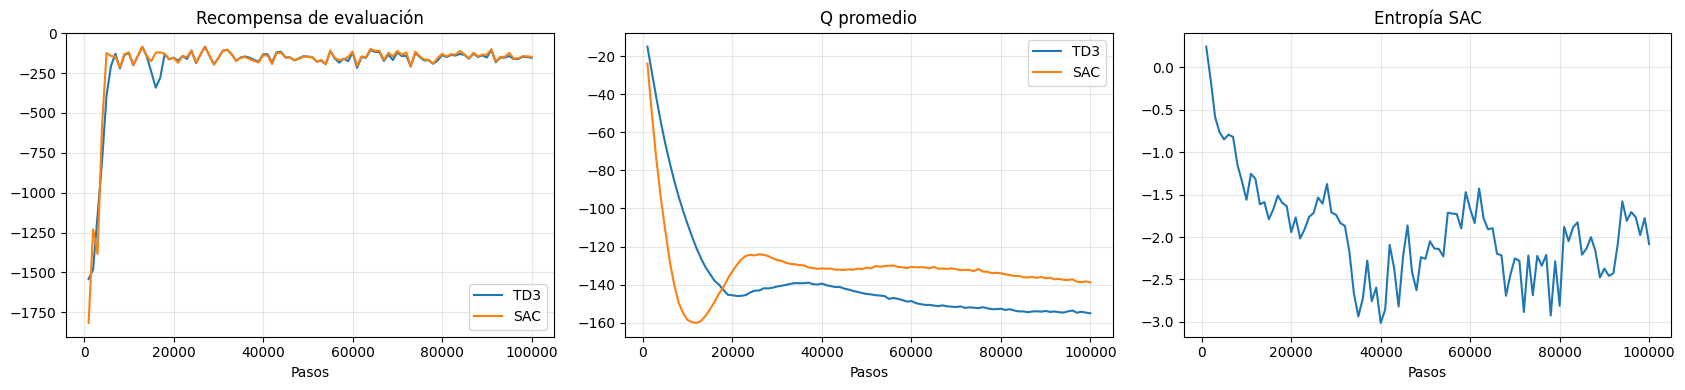

In [7]:
# Ejecución completa de Task 2.1. Está desactivada por defecto para evitar
# iniciar 200,000 pasos accidentalmente al abrir el notebook.
RUN_TASK_2_1 = True
TD3_METRICS = None
SAC_METRICS = None
if RUN_TASK_2_1:
    start = time.time()
    td3_agent, td3_buffer, td3_metrics = train_td3(total_steps= TOTAL_STEPS)
    TD3_METRICS = td3_metrics
    sac_agent, sac_buffer, sac_metrics = train_sac(total_steps= TOTAL_STEPS)
    SAC_METRICS = sac_metrics

    # Guardar las métricas en archivos CSV
    td3_metrics.to_csv('td3_metrics.csv', index=False)
    sac_metrics.to_csv('sac_metrics.csv', index=False)
    print('Métricas exportadas a td3_metrics.csv y sac_metrics.csv con éxito.')

    plot_task21_metrics(td3_metrics, sac_metrics)
    print('TD3 recompensa final:', td3_metrics.eval_return.iloc[-1])
    print('SAC recompensa final:', sac_metrics.eval_return.iloc[-1])
    print('Tiempo total:', round(time.time() - start, 1), 's')
else:
    print('Task 2.1 listo. Cambia RUN_TASK_2_1 a True para entrenar 100,000 pasos por algoritmo.')

In [6]:
from pandas.io.api import read_csv
TD3_METRICS = read_csv('td3_metrics.csv')
SAC_METRICS = read_csv('sac_metrics.csv')

### Task 2.2


Generen el dataset para el experimento de Offline RL entrenando primero una política subóptima sobre Pendulum-v1: entrenen TD3 durante solo 20,000 pasos (sin convergencia completa) y recolecten 50,000 transiciones con esa política más exploración adicional con ruido gaussiano 𝒩(0,0.3). Este dataset simula los registros históricos de operadores humanos con desempeño heterogéneo.

Implementen CQL sobre ese dataset. Usen la misma arquitectura de red que en Task 2.1. La pérdida de CQL debe incluir el término TD estándar más el término de regularización con 𝛼𝐶𝑄𝐿 ∈ {0.5,1.0,5.0}. Entrenen durante 100,000 actualizaciones sobre el dataset sin ninguna interacción adicional con el entorno.

Evalúen la política aprendida por CQL ejecutándola sobre el entorno real durante 10 episodios por cada valor de 𝛼𝐶𝑄𝐿. Comparen esa evaluación con la recompensa promedio de la política subóptima que generó el dataset.


In [6]:
class OfflineDataset:
    def __init__(self, data, device=DEVICE):
        self.data = {key: np.asarray(value, dtype=np.float32) for key, value in data.items()}
        self.size = len(self.data['states'])
        self.device = device

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        names = ('states', 'actions', 'rewards', 'next_states', 'not_done')
        return tuple(torch.as_tensor(self.data[name][idx], dtype=torch.float32, device=self.device) for name in names)

class CQLAgent:
    def __init__(self, state_dim, action_low, action_high, alpha_cql,
                 entropy_alpha=0.2, num_cql_actions=10):
        self.actor = GaussianActor(state_dim, action_low, action_high).to(DEVICE)
        self.critic = TwinCritic(state_dim, len(action_low)).to(DEVICE)
        self.critic_target = copy.deepcopy(self.critic).to(DEVICE)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=3e-4)
        self.alpha_cql = float(alpha_cql)
        self.entropy_alpha = float(entropy_alpha)
        self.num_cql_actions = int(num_cql_actions)
        self.action_low = torch.as_tensor(action_low, dtype=torch.float32, device=DEVICE)
        self.action_high = torch.as_tensor(action_high, dtype=torch.float32, device=DEVICE)
        self.log_action_volume = torch.log(torch.prod(self.action_high - self.action_low))

    @torch.no_grad()
    def act(self, state):
        state_t = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        action, _ = self.actor.sample(state_t, deterministic=True)
        return action.cpu().numpy()[0]

    def _cql_penalty(self, state, data_action):
        batch_size = state.shape[0]
        k = self.num_cql_actions
        repeated_state = state.unsqueeze(1).repeat(1, k, 1).reshape(batch_size * k, -1)
        random_action = self.action_low + torch.rand(batch_size * k, data_action.shape[-1], device=DEVICE) * (self.action_high - self.action_low)
        policy_action, policy_log_prob = self.actor.sample(repeated_state)
        q1_random, q2_random = self.critic(repeated_state, random_action)
        q1_policy, q2_policy = self.critic(repeated_state, policy_action.detach())
        q1_random = q1_random.reshape(batch_size, k) + self.log_action_volume
        q2_random = q2_random.reshape(batch_size, k) + self.log_action_volume
        q1_policy = q1_policy.reshape(batch_size, k) - policy_log_prob.detach().reshape(batch_size, k)
        q2_policy = q2_policy.reshape(batch_size, k) - policy_log_prob.detach().reshape(batch_size, k)
        samples_q1 = torch.cat([q1_random, q1_policy], dim=1)
        samples_q2 = torch.cat([q2_random, q2_policy], dim=1)
        q1_data = self.critic.q1(state, data_action).squeeze(-1)
        q2_data = self.critic(state, data_action)[1].squeeze(-1)
        penalty_1 = torch.logsumexp(samples_q1, dim=1) - np.log(2 * k) - q1_data
        penalty_2 = torch.logsumexp(samples_q2, dim=1) - np.log(2 * k) - q2_data
        return penalty_1.mean(), penalty_2.mean()

    def update(self, dataset, batch_size=BATCH_SIZE):
        state, action, reward, next_state, not_done = dataset.sample(batch_size)
        with torch.no_grad():
            next_action, next_log_prob = self.actor.sample(next_state)
            target_q1, target_q2 = self.critic_target(next_state, next_action)
            target = reward + GAMMA * not_done * (torch.minimum(target_q1, target_q2) - self.entropy_alpha * next_log_prob)
        q1, q2 = self.critic(state, action)
        td_loss = (q1 - target).pow(2).mean() + (q2 - target).pow(2).mean()
        cql1, cql2 = self._cql_penalty(state, action)
        critic_loss = td_loss + self.alpha_cql * (cql1 + cql2)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        new_action, log_prob = self.actor.sample(state)
        new_q1, new_q2 = self.critic(state, new_action)
        actor_loss = (self.entropy_alpha * log_prob - torch.minimum(new_q1, new_q2)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        soft_update(self.critic, self.critic_target, TAU)
        return {'critic_loss': critic_loss.item(), 'td_loss': td_loss.item(),
                'cql_penalty': (cql1 + cql2).item(), 'actor_loss': actor_loss.item()}

def collect_offline_dataset(agent, n_transitions=50_000, noise_std=0.3,
                            env_name='Pendulum-v1', seed=SEED):
    env = gym.make(env_name)
    state, _ = env.reset(seed=seed)
    low = env.action_space.low.astype(np.float32)
    high = env.action_space.high.astype(np.float32)
    states, actions, rewards, next_states, not_done = [], [], [], [], []
    for _ in range(n_transitions):
        base_action = agent.act(state)
        action = np.clip(base_action + np.random.normal(0.0, noise_std, size=low.shape), low, high)
        next_state, reward, terminated, truncated, _ = env.step(action)
        states.append(state); actions.append(action); rewards.append([reward])
        next_states.append(next_state); not_done.append([1.0 - float(terminated)])
        state = next_state
        if terminated or truncated:
            state, _ = env.reset()
    env.close()
    return {'states': np.asarray(states, dtype=np.float32),
            'actions': np.asarray(actions, dtype=np.float32),
            'rewards': np.asarray(rewards, dtype=np.float32),
            'next_states': np.asarray(next_states, dtype=np.float32),
            'not_done': np.asarray(not_done, dtype=np.float32)}

def train_cql(dataset, state_dim, action_low, action_high, alpha_cql,
              updates=100_000, batch_size=BATCH_SIZE, log_interval=1_000):
    agent = CQLAgent(state_dim, action_low, action_high, alpha_cql)
    history = []
    for update in range(1, updates + 1):
        metrics = agent.update(dataset, batch_size)
        if update % log_interval == 0:
            history.append({'update': update, **metrics})
    return agent, pd.DataFrame(history)

def run_task_2_2(seed=SEED, td3_steps=20_000, dataset_size=50_000, cql_updates=100_000):
    seed_everything(seed)
    generator, _, _ = train_td3(total_steps=td3_steps, record_metrics=False, seed=seed)
    baseline_mean, baseline_std = evaluate_agent(generator, episodes=10, seed=seed + 20_000)
    data = collect_offline_dataset(generator, dataset_size, noise_std=0.3, seed=seed + 1)
    offline = OfflineDataset(data)
    _, state_dim, action_low, action_high, _ = _make_env_info('Pendulum-v1', seed)
    results = []
    agents = {}
    histories = {}
    for alpha_cql in (0.5, 1.0, 5.0):
        agent, history = train_cql(offline, state_dim, action_low, action_high, alpha_cql, cql_updates)
        # Exportar historial de entrenamiento del agente CQL a CSV
        history.to_csv(f'cql_metrics_alpha_{alpha_cql}.csv', index=False)
        print(f'Métricas de CQL con alpha={alpha_cql} guardadas en cql_metrics_alpha_{alpha_cql}.csv')

        mean_return, std_return = evaluate_agent(agent, episodes=10, seed=seed + int(alpha_cql * 100))
        results.append({'alpha_cql': alpha_cql, 'mean_return': mean_return, 'std_return': std_return,
                        'baseline_mean_return': baseline_mean, 'baseline_std_return': baseline_std})
        agents[alpha_cql] = agent
        histories[alpha_cql] = history

    results_df = pd.DataFrame(results)
    results_df.to_csv('cql_results.csv', index=False)
    print('Resultados globales de CQL guardados en cql_results.csv')

    return {'generator': generator, 'dataset': data, 'baseline_mean': baseline_mean,
            'baseline_std': baseline_std, 'results': results_df,
            'agents': agents, 'histories': histories}

def plot_cql_results(cql_output):
    table = cql_output['results']
    x = np.arange(len(table))
    plt.figure(figsize=(8, 4))
    plt.bar(x, table.mean_return, yerr=table.std_return, capsize=4, label='CQL')
    plt.axhline(cql_output['baseline_mean'], color='black', linestyle='--', label='Política generadora')
    plt.xticks(x, [str(a) for a in table.alpha_cql])
    plt.xlabel('alpha_CQL'); plt.ylabel('Recompensa promedio')
    plt.title('Evaluación offline de CQL')
    plt.grid(axis='y', alpha=0.3); plt.legend(); plt.tight_layout()
    return plt.gcf()

Métricas de CQL con alpha=0.5 guardadas en cql_metrics_alpha_0.5.csv
Métricas de CQL con alpha=1.0 guardadas en cql_metrics_alpha_1.0.csv
Métricas de CQL con alpha=5.0 guardadas en cql_metrics_alpha_5.0.csv
Resultados globales de CQL guardados en cql_results.csv


,alpha_cql,mean_return,std_return,baseline_mean_return,baseline_std_return
0,0.5,-157.167833,52.240384,-154.570067,51.068519
1,1.0,-314.582741,275.201884,-154.570067,51.068519
2,5.0,-171.010819,78.704639,-154.570067,51.068519


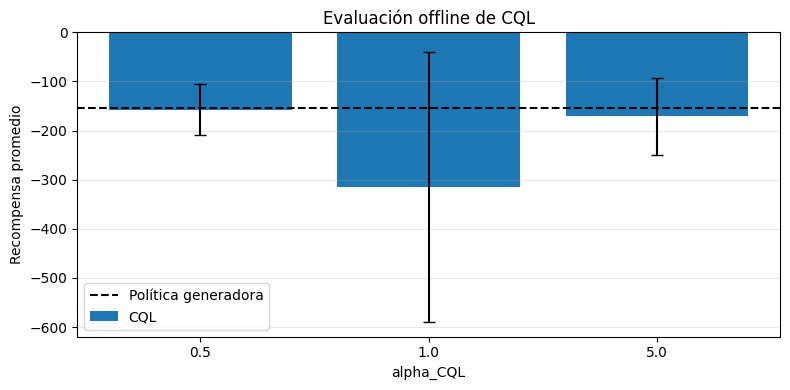

In [8]:
# Ejecución completa de Task 2.2. Requiere primero disponer de las dependencias
# y puede tardar bastante por las 20,000 + 3 x 100,000 actualizaciones.
RUN_TASK_2_2 = True

if RUN_TASK_2_2:
    cql_output = run_task_2_2()
    display(cql_output['results'])
    plot_cql_results(cql_output)
else:
    print('Task 2.2 listo. Cambia RUN_TASK_2_2 a True para generar el dataset y entrenar CQL.')


In [10]:
TD3_METRICS = pd.read_csv('td3_metrics.csv')
SAC_METRICS = pd.read_csv('sac_metrics.csv')
CQL_05 = pd.read_csv('cql_metrics_alpha_0.5.csv')
CQL_10 = pd.read_csv('cql_metrics_alpha_1.0.csv')
CQL_50 = pd.read_csv('cql_metrics_alpha_5.0.csv')

### Task 2.3

Con base en los resultados de ambos experimentos, respondan:


a. **Grafiquen las curvas de aprendizaje de TD3 y SAC en la misma figura con media móvil de 10 evaluaciones. ¿Cuál converge más rápido? ¿Cuál alcanza mayor recompensa final? ¿El resultado
coincide con la predicción teórica de la Task 1.1b? Si hay discrepancia, argumenten la causa.**


In [11]:
def plot_learning_curves(td3_metrics, sac_metrics, window=10):
    fig, ax = plt.subplots(figsize=(10, 5))
    for name, metrics, color in [('TD3', td3_metrics, 'tab:blue'), ('SAC', sac_metrics, 'tab:orange')]:
        rolling = metrics.eval_return.rolling(window, min_periods=1).mean()
        rolling_std = metrics.eval_return.rolling(window, min_periods=1).std().fillna(0.0)
        ax.plot(metrics.step, metrics.eval_return, color=color, alpha=0.25, linewidth=1)
        ax.plot(metrics.step, rolling, color=color, linewidth=2,
                label=f'{name} (media móvil {window} eval.)')
        ax.fill_between(metrics.step, rolling - rolling_std, rolling + rolling_std,
                        color=color, alpha=0.12)
    ax.set_title('Curvas de aprendizaje TD3 vs SAC (Pendulum-v1)')
    ax.set_xlabel('Pasos de entorno')
    ax.set_ylabel('Recompensa promedio de evaluación (10 episodios)')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()


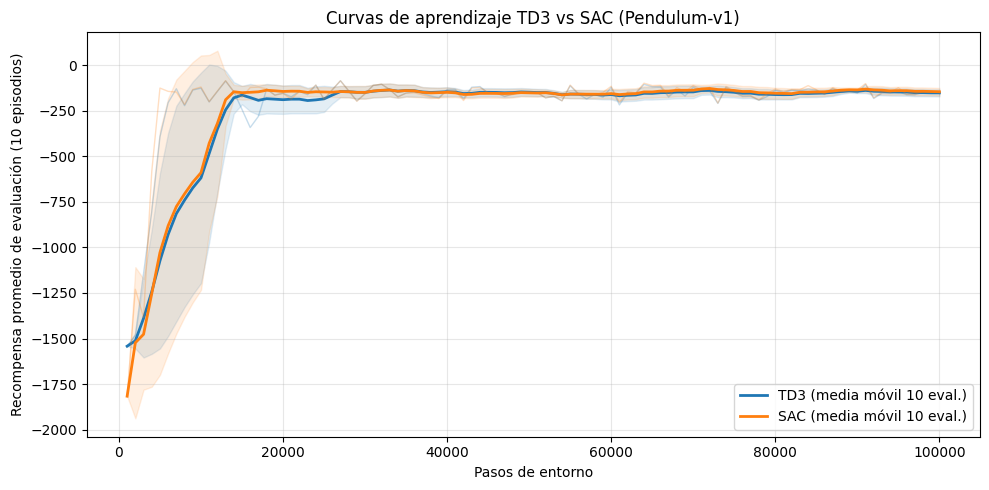

In [12]:
plot_learning_curves(TD3_METRICS, SAC_METRICS)
plt.show()

def convergence_summary(metrics_by_name, window=10, thresholds=(-300, -200, -160)):
    rows = []
    for name, metrics in metrics_by_name.items():
        rolling = metrics.eval_return.rolling(window, min_periods=1).mean()
        row = {'algoritmo': name}
        for th in thresholds:
            reached = metrics.step[rolling >= th]
            row[f'pasos hasta MM >= {th}'] = int(reached.iloc[0]) if len(reached) else np.nan
        row['mejor MM'] = rolling.max()
        row['paso mejor MM'] = int(metrics.step[rolling.idxmax()])
        row['final (últimas 10 eval.)'] = metrics.eval_return.tail(window).mean()
        row['std final (últimas 10 eval.)'] = metrics.eval_return.tail(window).std()
        rows.append(row)
    return pd.DataFrame(rows).set_index('algoritmo')

display(convergence_summary({'TD3': TD3_METRICS, 'SAC': SAC_METRICS}).round(1).T)


> Converge mas rápido SAC, en alrededor de 10k pasos menos, pero ambos parecen acercarse a la misma recompenza. Ahora con la prediccion de la task 1.1, resulto no ser del todo cierta, pues SAC converge más rápido que TD3 en la semilla analizada a pesar de estar en un entorno suave donde en teoría TD3 es más eficiente. Sin embargo, la recompenza final siendo la misma si se cumple en la preiccion. Como recomendación final, la predicción realizada no se contradice, nosotros evaluamos una misma semilla y generalmente se considera TD3 como apropiado, asimismo, TD3 mostró eventualmente llegar al mismo nivel de recompenza ideal con una politica determinista, por lo que su recomendación se mantiene.

b. **Grafiquen el valor Q promedio durante el entrenamiento para TD3 y SAC. ¿Observan diferencias en la magnitud de los valores estimados? Conéctenlo con el análisis de conservatividad de la Task 1.2b.**


algoritmo,TD3,SAC
Q medio (todo el entrenamiento),-138.464,-131.345
Q medio (últimas 10 eval.),-154.347,-137.667
retorno eval. (últimas 10),-151.571,-145.430
α final,NaN,0.043
entropía final,NaN,-1.966
bono entropía ≈ α·H/(1−γ),NaN,-10.546


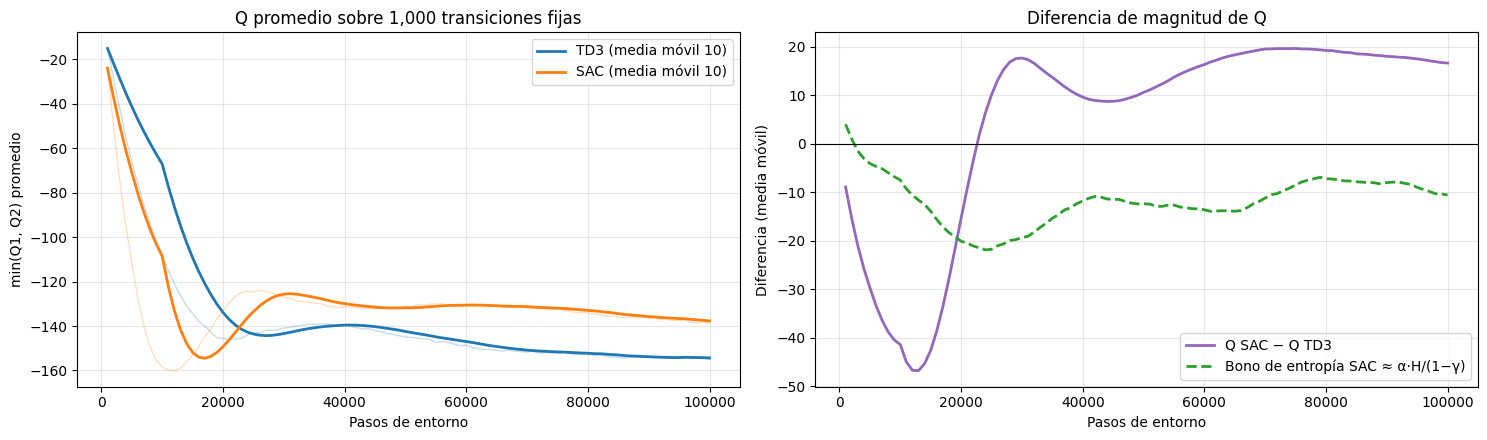

In [13]:
def plot_q_values(td3_metrics, sac_metrics, window=10, gamma=GAMMA):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    ax = axes[0]
    for name, metrics, color in [('TD3', td3_metrics, 'tab:blue'), ('SAC', sac_metrics, 'tab:orange')]:
        ax.plot(metrics.step, metrics.q_mean, color=color, alpha=0.25, linewidth=1)
        ax.plot(metrics.step, metrics.q_mean.rolling(window, min_periods=1).mean(), color=color,
                linewidth=2, label=f'{name} (media móvil {window})')
    ax.set_title('Q promedio sobre 1,000 transiciones fijas')
    ax.set_xlabel('Pasos de entorno'); ax.set_ylabel('min(Q1, Q2) promedio')
    ax.legend(); ax.grid(alpha=0.3)

    # Diferencia SAC - TD3 y contribución aproximada del bono de entropía al valor soft:
    # alpha * H / (1 - gamma) es lo que suma el término -alpha*log(pi) en un horizonte descontado.
    ax = axes[1]
    merged = td3_metrics[['step', 'q_mean']].merge(sac_metrics[['step', 'q_mean', 'entropy', 'alpha']],
                                                    on='step', suffixes=('_td3', '_sac'))
    diff = (merged.q_mean_sac - merged.q_mean_td3).rolling(window, min_periods=1).mean()
    entropy_bonus = (merged.alpha * merged.entropy / (1.0 - gamma)).rolling(window, min_periods=1).mean()
    ax.plot(merged.step, diff, color='tab:purple', linewidth=2, label='Q SAC − Q TD3')
    ax.plot(merged.step, entropy_bonus, color='tab:green', linewidth=2, linestyle='--',
            label='Bono de entropía SAC ≈ α·H/(1−γ)')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Diferencia de magnitud de Q')
    ax.set_xlabel('Pasos de entorno'); ax.set_ylabel('Diferencia (media móvil)')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

def q_value_summary(td3_metrics, sac_metrics, window=10, gamma=GAMMA):
    rows = []
    for name, metrics in [('TD3', td3_metrics), ('SAC', sac_metrics)]:
        returns = metrics.eval_return.tail(window).mean()
        row = {'algoritmo': name,
               'Q medio (todo el entrenamiento)': metrics.q_mean.mean(),
               'Q medio (últimas 10 eval.)': metrics.q_mean.tail(window).mean(),
               'retorno eval. (últimas 10)': returns}
        if 'entropy' in metrics and metrics.entropy.notna().any():
            row['α final'] = metrics.alpha.iloc[-1]
            row['entropía final'] = metrics.entropy.tail(window).mean()
            row['bono entropía ≈ α·H/(1−γ)'] = (metrics.alpha * metrics.entropy).tail(window).mean() / (1.0 - gamma)
        rows.append(row)
    return pd.DataFrame(rows).set_index('algoritmo')

plot_q_values(TD3_METRICS, SAC_METRICS)
display(q_value_summary(TD3_METRICS, SAC_METRICS).round(3).T)


> Si se encuentra una diferencia en las magnitudes con dos fases distintas. Previo a los 20k cuando ambos agentes estan convergiendo, TD3 parece tener un mayor valor estimado de Q, pero luego de este punto, SAC continua estimando una mayor magnitud de Q durante el resto del entrenamiento. Este pesimismo de TD3 sistematico al continuar los pasos no parece tener un efecto correlacionado con el retorno de ambos agentes, es decir, sus predicciones conservadoras si llegan a la politica correcta. Esto es exactamente lo que indica la conclusion de la task 1.2b dado que aunque TD3 es mas conservador, corrige el mecanismo propuesto donde SAC sobre estima por un valor proporcional a $\alpha H$

c. **Para el experimento de CQL: ¿alguno de los tres valores de 𝛼𝐶𝑄𝐿 produce una política que supera a la política subóptima que generó el dataset? ¿Cuál valor de 𝛼𝐶𝑄𝐿 funciona mejor y por qué? Si ningún valor supera al dataset, argumenten a qué atribuyen ese resultado considerando las características del dataset que generaron.**


,mean_return,std_return,baseline_mean_return,baseline_std_return,diferencia vs dataset,diferencia %,z (diferencia / SE),supera al dataset
alpha_cql,,,,,,,,
0.5,-157.17,52.24,-154.57,51.07,-2.60,-1.68,-0.11,False
1.0,-314.58,275.20,-154.57,51.07,-160.01,-103.52,-1.81,False
5.0,-171.01,78.70,-154.57,51.07,-16.44,-10.64,-0.55,False


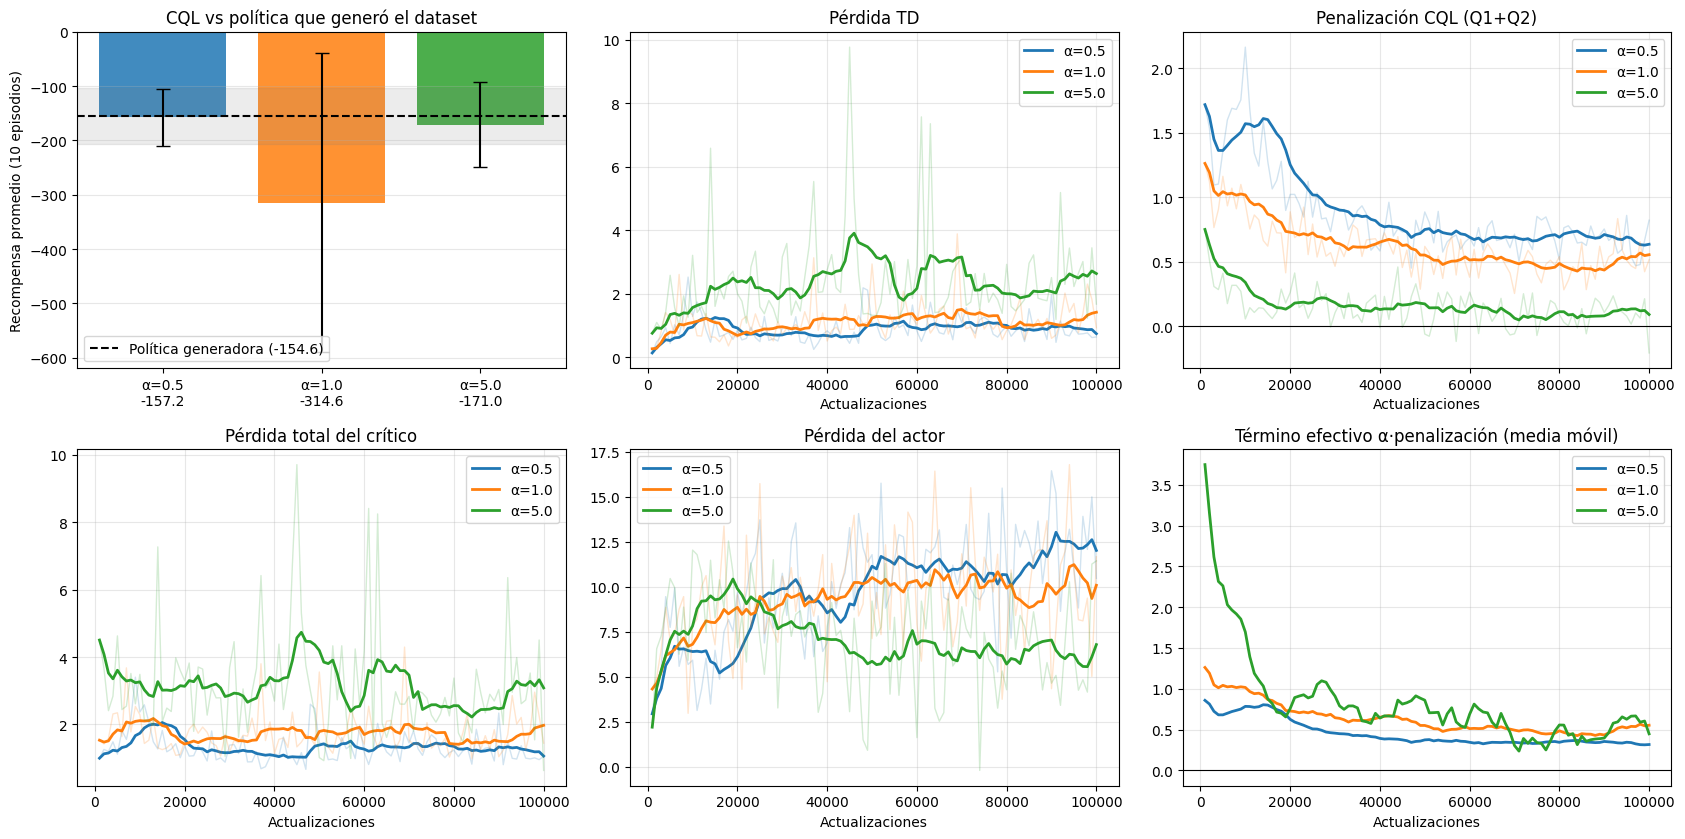

In [15]:
import os

# Si cql_results.csv no está disponible (p. ej. se ejecutó en Colab), se usan los valores
# impresos por la ejecución de Task 2.2.
if os.path.exists('cql_results.csv'):
    CQL_RESULTS = pd.read_csv('cql_results.csv')
else:
    CQL_RESULTS = pd.DataFrame({
        'alpha_cql': [0.5, 1.0, 5.0],
        'mean_return': [-157.167833, -314.582741, -171.010819],
        'std_return': [52.240384, 275.201884, 78.704639],
        'baseline_mean_return': [-154.570067] * 3,
        'baseline_std_return': [51.068519] * 3,
    })
CQL_HISTORIES = {0.5: CQL_05, 1.0: CQL_10, 5.0: CQL_50}

def cql_comparison_table(results, episodes=10):
    table = results.copy()
    table['diferencia vs dataset'] = table.mean_return - table.baseline_mean_return
    table['diferencia %'] = 100 * table['diferencia vs dataset'] / table.baseline_mean_return.abs()
    # Error estándar de la diferencia entre dos medias de 10 episodios (Welch)
    se = np.sqrt(table.std_return ** 2 / episodes + table.baseline_std_return ** 2 / episodes)
    table['z (diferencia / SE)'] = table['diferencia vs dataset'] / se
    table['supera al dataset'] = table['diferencia vs dataset'] > 0
    return table.set_index('alpha_cql')

def plot_cql_analysis(results, histories, window=10):
    colors = {0.5: 'tab:blue', 1.0: 'tab:orange', 5.0: 'tab:green'}
    fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))

    ax = axes[0, 0]
    x = np.arange(len(results))
    ax.bar(x, results.mean_return, yerr=results.std_return, capsize=5,
           color=[colors[a] for a in results.alpha_cql], alpha=0.85)
    base_mean, base_std = results.baseline_mean_return.iloc[0], results.baseline_std_return.iloc[0]
    ax.axhline(base_mean, color='black', linestyle='--', label=f'Política generadora ({base_mean:.1f})')
    ax.axhspan(base_mean - base_std, base_mean + base_std, color='gray', alpha=0.15)
    ax.set_xticks(x, [f'α={a}\n{v:.1f}' for a, v in zip(results.alpha_cql, results.mean_return)])
    ax.set_ylabel('Recompensa promedio (10 episodios)')
    ax.set_title('CQL vs política que generó el dataset')
    ax.legend(loc='lower left'); ax.grid(axis='y', alpha=0.3)

    panels = [('td_loss', 'Pérdida TD'), ('cql_penalty', 'Penalización CQL (Q1+Q2)'),
              ('critic_loss', 'Pérdida total del crítico'), ('actor_loss', 'Pérdida del actor')]
    for ax, (col, title) in zip([axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1]], panels):
        for alpha_cql, history in histories.items():
            ax.plot(history['update'], history[col], color=colors[alpha_cql], alpha=0.2, linewidth=1)
            ax.plot(history['update'], history[col].rolling(window, min_periods=1).mean(),
                    color=colors[alpha_cql], linewidth=2, label=f'α={alpha_cql}')
        if col == 'cql_penalty':
            ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(title); ax.set_xlabel('Actualizaciones'); ax.grid(alpha=0.3); ax.legend()

    # Contribución efectiva del regularizador: alpha * penalización
    ax = axes[1, 2]
    for alpha_cql, history in histories.items():
        ax.plot(history['update'], (alpha_cql * history.cql_penalty).rolling(window, min_periods=1).mean(),
                color=colors[alpha_cql], linewidth=2, label=f'α={alpha_cql}')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Término efectivo α·penalización (media móvil)')
    ax.set_xlabel('Actualizaciones'); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()

display(cql_comparison_table(CQL_RESULTS).round(2))
plot_cql_analysis(CQL_RESULTS, CQL_HISTORIES)


> Ninguno de los tres valores de $\alpha CQL$ supera la politica suboptima generada por el dataset. La mas cercana es la de $\alpha = 0.5$ con -157.2 que queda por ~1.7% debajo de dicha politica. Este valor funciona mejor porque es la penalizacion más debil que permite un menor rango d desviación del dataset. Asmismo, que ninguno supere el dataset se puede explicar con la generacion misma de la politica subotima. TD3 online estaba cerca del techo del Pendulim y los datos vienen de una sola politica con ruido gausiano sin realmente una diversidad de comportamiento que CQL pueda mejorar. 

d. **Conexión entre paradigmas: con base en los resultados de ambos experimentos, argumenten cuándo recomendarían usar TD3 o SAC versus CQL para el sistema de turbinas eólicas real. Consideren explícitamente: disponibilidad de un simulador confiable, costo de interacción con el sistema real, calidad del dataset histórico disponible, y urgencia de despliegue. Esta pregunta no puede responderse correctamente sin los resultados específicos de sus experimentos.**


,retorno,std,interacciones con el entorno,interacción durante entrenamiento
método,,,,
TD3 (online),-151.6,19.3,100000,sí
SAC (online),-145.4,20.9,100000,sí
Política generadora (TD3 20k),-154.6,51.1,20000,sí
Mejor CQL (α=0.5),-157.2,52.2,70000,no (solo dataset)


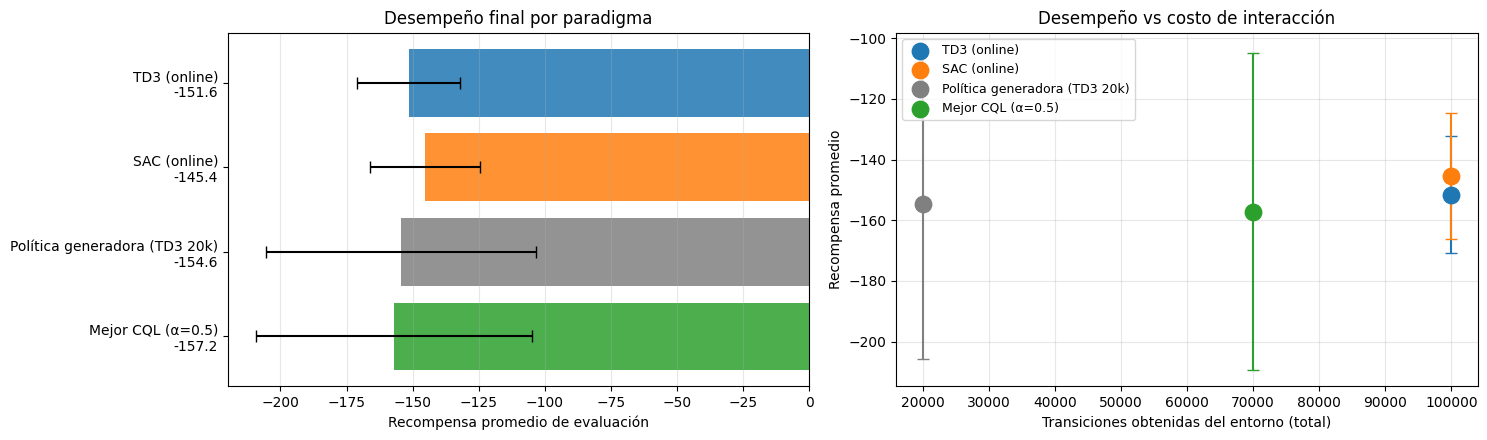

In [17]:
def paradigm_summary(td3_metrics, sac_metrics, cql_results, window=10,
                     online_steps=100_000, generator_steps=20_000, dataset_size=50_000):
    best = cql_results.loc[cql_results.mean_return.idxmax()]
    rows = [
        {'método': 'TD3 (online)', 'retorno': td3_metrics.eval_return.tail(window).mean(),
         'std': td3_metrics.eval_return.tail(window).std(), 'interacciones con el entorno': online_steps,
         'interacción durante entrenamiento': 'sí'},
        {'método': 'SAC (online)', 'retorno': sac_metrics.eval_return.tail(window).mean(),
         'std': sac_metrics.eval_return.tail(window).std(), 'interacciones con el entorno': online_steps,
         'interacción durante entrenamiento': 'sí'},
        {'método': 'Política generadora (TD3 20k)', 'retorno': best.baseline_mean_return,
         'std': best.baseline_std_return, 'interacciones con el entorno': generator_steps,
         'interacción durante entrenamiento': 'sí'},
        {'método': f'Mejor CQL (α={best.alpha_cql})', 'retorno': best.mean_return,
         'std': best.std_return, 'interacciones con el entorno': generator_steps + dataset_size,
         'interacción durante entrenamiento': 'no (solo dataset)'},
    ]
    return pd.DataFrame(rows).set_index('método')

def plot_paradigm_comparison(summary):
    colors = ['tab:blue', 'tab:orange', 'gray', 'tab:green']
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    ax = axes[0]
    labels = [f'{name}\n{v:.1f}' for name, v in zip(summary.index, summary.retorno)]
    ax.barh(labels, summary.retorno, xerr=summary['std'], capsize=4, color=colors, alpha=0.85)
    ax.set_xlabel('Recompensa promedio de evaluación'); ax.set_title('Desempeño final por paradigma')
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)

    ax = axes[1]
    for (name, row), color in zip(summary.iterrows(), colors):
        ax.scatter(row['interacciones con el entorno'], row.retorno, s=140, color=color, label=name, zorder=3)
        ax.errorbar(row['interacciones con el entorno'], row.retorno, yerr=row['std'], color=color,
                    capsize=4, zorder=2)
    ax.set_xlabel('Transiciones obtenidas del entorno (total)')
    ax.set_ylabel('Recompensa promedio'); ax.set_title('Desempeño vs costo de interacción')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()

PARADIGMS = paradigm_summary(TD3_METRICS, SAC_METRICS, CQL_RESULTS)
display(PARADIGMS.round(1))
plot_paradigm_comparison(PARADIGMS)


> Si tomamos en cuenta la existencia de un simulador confiable tanto TD3 como SAC muestran resultados de entrenamiento sin mejoras considerables dentro del experimento con CQL, idealmente TD3, el cual produce una politica determinista que puede ser mas util en producción.
>En terminos de costo de interacción con un sistema real, CQL sería ideal, pues se entreno sin información del entorno y logro igual llegar acercarse a la política óptima con tan solo una fracción de los pasos que le tomo a TD3 y SAC; asimismo, TD3 y SAC tomaron decisiones casi aleatorias en los primeros pasos, lo cual puede ser muy irresponsable en un sistema de turbinas reales.
>Con un dataset historico de buena covertura con comportamientos realmente diversos CQL conviene, pues en nuestro experimento basicamente solo igualo a politica que genero los datos, por tanto si nuestros datos no son realmente de comportamientos diversos, se reomienda TD3 por las mismas razones del punto 1.
> Si hay urgencia de despliegue CQL con un $\alpha$ bajo como 0.5 genera rapidamente una politica con desempeño comparable a los generadores sin riesgos de exploracion y decisiones aleatorias. 
Finalmente, se recomienda CQL con un alpha bajo como punto de partida, pues es el mas seguro en general, y mostro poder igualar a la politica generadora de datos con pocos pasos en los experimentos realizados, y no los supero unicamente por falta de diversidad en los datos.

e. **Investigación bibliográfica: busquen y lean un paper publicado entre 2023 y 2025 que aplique Offline RL (CQL, BCQ, IQL, o variantes) a un problema de control de sistemas energéticos, robótica industrial, o infraestructura física. El paper debe ser de NeurIPS, ICML, ICLR, IEEE Transactions on Power Systems, o similar. Escriban un resumen técnico de media página con: el problema que resuelve, qué algoritmo de Offline RL usa y por qué, los resultados principales, y una reflexión sobre si las limitaciones del dataset que identificaron en la Task 1.1c también aparecen en ese trabajo y cómo las manejan.**


1. Referencia
Y. Huang y X. Zhao, "Wind Farm Control via Offline Reinforcement Learning with Adversarial Training," IEEE Transactions on Automation Science and Engineering, vol. 22, pp. 12845–12856, 2025. DOI: 10.1109/TASE.2025.3548565.

2. Problemática
En un parque eólico, la estela de las turbinas de adelante reduce el viento que reciben las de atrás, y con eso baja la generación total. Entrenar un controlador cooperativo con RL online necesita millones de interacciones con un simulador CFD. Los autores estiman ~2.8 TB de memoria y ~1,342 GPU-horas solo para recolectar 10⁶ muestras, además de la brecha sim2real. En cambio, los parques ya tienen grandes registros históricos de operación. Cada turbina es un agente: observa 24 variables locales, actúa sobre el yaw y el coeficiente de empuje (pitch/velocidad del rotor), y su recompensa es proporcional a la potencia generada

3. Algoritmo
Proponen MAOBI (Multi-Agent Offline Behavior Imitation). Tiene dos partes:

- Clonación de comportamiento con f-GAN: un discriminador estima la divergencia entre la política aprendida y la de comportamiento, y el actor la minimiza. Así la política no se sale del soporte de los datos.

- Selección de comportamiento: usa un objetivo tipo PPO con clipping y ventaja G(s,a) para preferir los pares estado-acción de alto retorno cuando el dataset tiene acciones contradictorias de controladores de distinta calidad.
Lo eligen porque los métodos online (PPO, DDPG) fallan con datos fijos por covariate shift y sesgo en la estimación de valor, y porque BC y BRAC solos no logran mejorar la política del dataset. Usan entrenamiento centralizado con ejecución descentralizada (CTDE), así que en operación las turbinas no necesitan comunicarse entre sí.

4. Resultados
- Simulado en SOWFA (CFD de alta fidelidad) con turbinas NREL 5MW, en tres layouts: grid de 9 turbinas, aleatorio y el parque real C-Power.
- +16.16 % de potencia promedio sobre MPPT (greedy), por encima de los controladores basados en modelo PWS (+6.95 %) y FVWC (+12.16 %).
- En C-Power, MAOBI genera 121.63 MW frente a 121.87 MW del MAPPO online, con 23.2 GPU-h de entrenamiento frente a 3,475.6 (el texto menciona 16.4 h; la tabla dice 23.2). Además tiene la menor fluctuación de potencia (9.98 MW).
- BC y BRAC no mejoran sobre el dataset. En la ablación, sin el clipping la política no mejora nada, y sin la divergencia f-GAN aprende más lento y queda subóptima

5. Reflexion
Política de comportamiento β: su dataset es una mezcla de controladores heterogéneos (MPPT, wake steering, MAPPO, HAPPO, MAIPO y una política aleatoria), parecida a nuestra β de "operadores con distinta experiencia". La diferencia clave es que incluye trayectorias de MAPPO, que ya es casi óptimo. MAOBI alcanza a MAPPO, pero no lo supera. El resultado demuestra que se puede recuperar el mejor comportamiento presente en los datos, no superarlo.
Cobertura: el dataset sale de un simulador e incluye una política aleatoria, así que su cobertura es artificialmente amplia, mucho mayor que la de registros de operadores reales, que evitan estados riesgosos. Además, la evaluación usa condiciones estrechas (dirección 260° ± 10°, viento de 8–10 m/s), sin ráfagas extremas ni fallas. La condición que identificamos como más difícil, la cobertura de estados críticos, no se pone a prueba.
Cómo lo manejan: la heterogeneidad la tratan con la selección por ventaja, que filtra los datos malos. La falta de soporte la tratan con la restricción de divergencia, que cumple un papel equivalente al término conservador de CQL. El error de extrapolación lo evitan quedándose cerca de β, pero no resuelven la falta de datos en regiones no observadas.

6. Adaptación en nuestro caso de uso
Su hallazgo coincide con nuestro experimento: los métodos que solo imitan o restringen (BC, BRAC, y nuestro CQL con α alto) no superan al dataset. Para mejorar se necesitan datos con comportamientos de alto retorno y un mecanismo para seleccionarlos. Nuestro dataset venía de una sola política casi óptima más ruido gaussiano, así que no había nada mejor que seleccionar. Por eso CQL con α = 0.5 solo empató con la política generadora (−157.2 vs −154.6).
Para la turbina real: con registros de operadores heterogéneos, cabe esperar que un método offline llegue al nivel del mejor operador del histórico, no más allá. Como en esos registros no habrá un "MAPPO" casi óptimo, el techo es más bajo que en el paper. Conviene combinar la conservatividad de CQL (α bajo) con ponderación por ventaja (IQL/AWR o una selección como la de MAOBI) para aprovechar a los operadores expertos.
Costo: su diferencia de ~150× en GPU-horas respalda nuestra conclusión de la parte d. Offline RL es el punto de partida barato y seguro, y el ajuste fino con simulador (TD3) se deja para cuando exista un simulador confiable.